# Progetto 4 — Pipeline di Regressione sul Dataset Diabetes

Confronto e ottimizzazione di modelli di regressione (Regressione Lineare, Decision Tree, Ridge, Lasso, KNN, SVM) per stimare un target numerico continuo.

## 1. Data Exploration & Preprocessing

### 1.1 Caricamento e Analisi del dataset

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

from sklearn.datasets import load_diabetes
from sklearn.decomposition import PCA
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    GridSearchCV,
    learning_curve,
)
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

In [61]:
data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

df = X.copy()
df['target'] = y
display(df)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [62]:
print(df.describe())

                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.268604e-17  1.130318e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.

### 1.2 Visualizzazione grafica (distribuzioni, outlier, correlazioni)

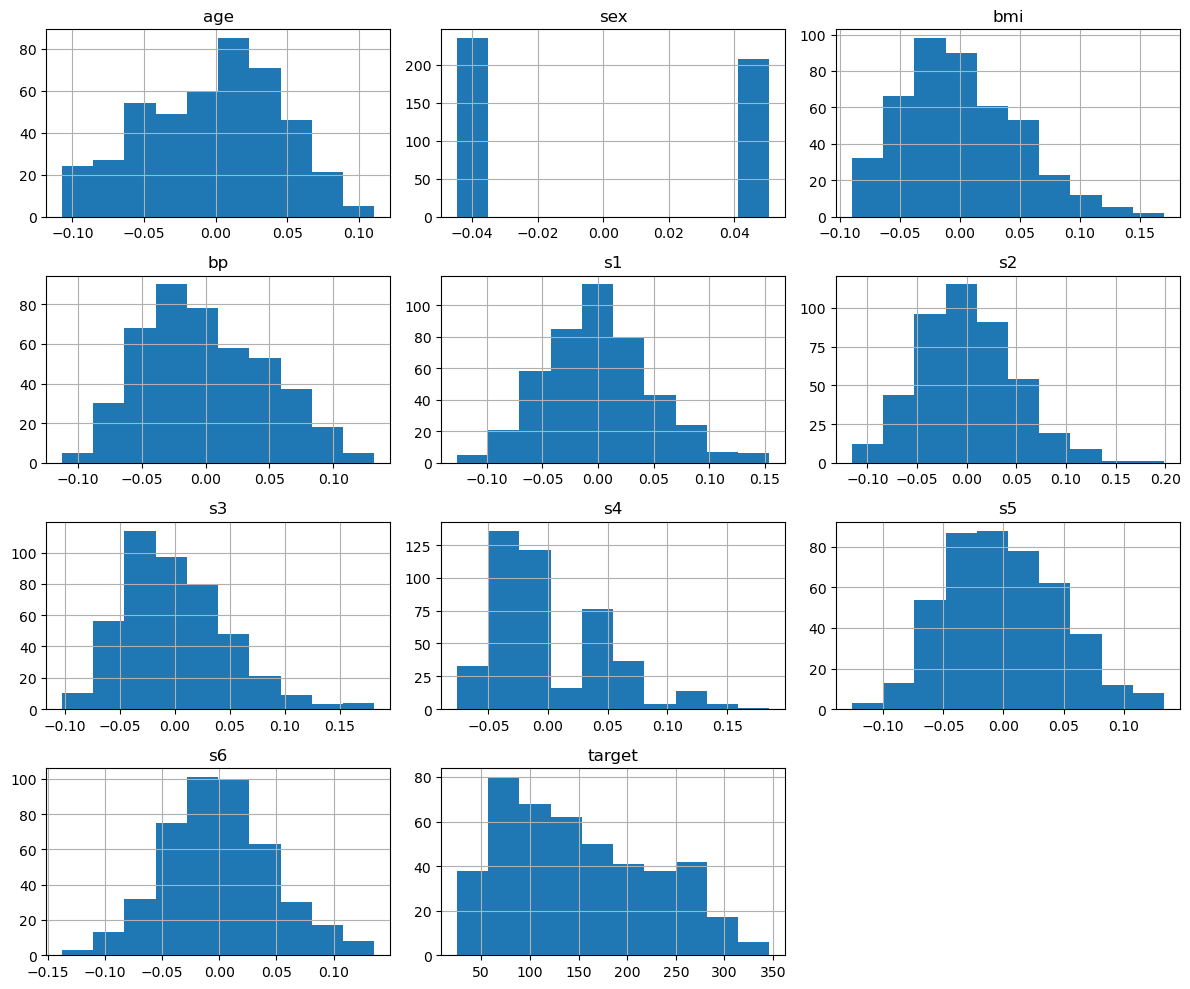

In [63]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

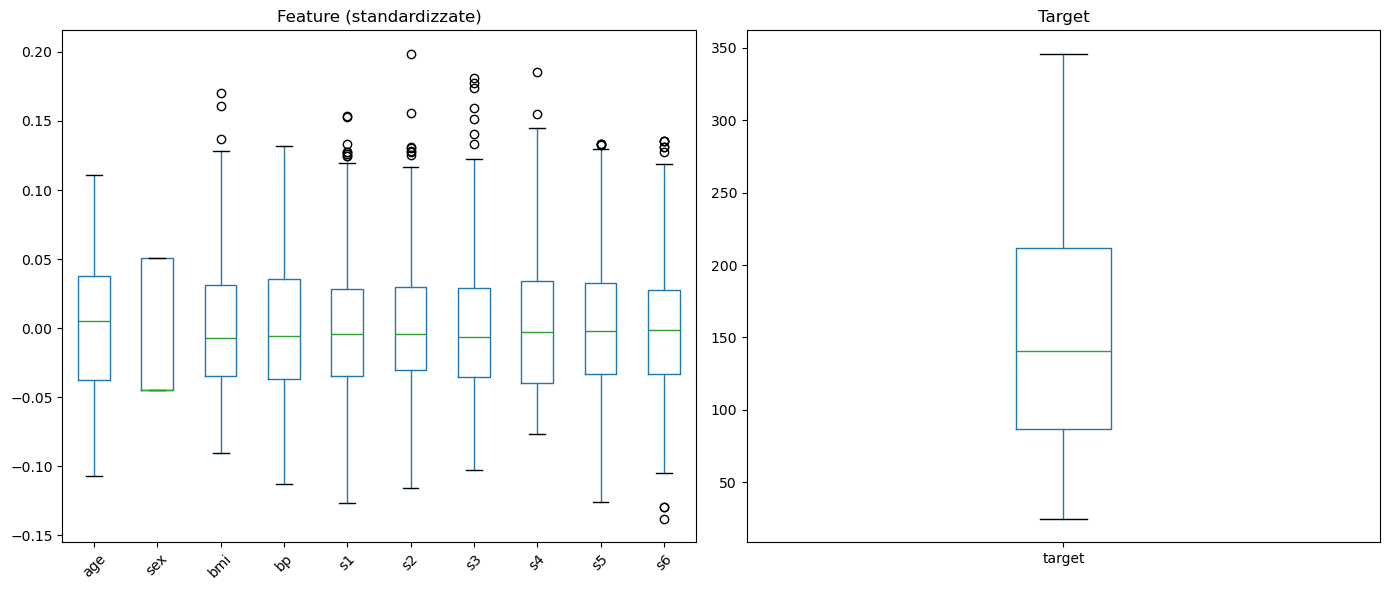

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
df.drop(columns='target').boxplot(ax=axes[0], grid=False, rot=45)
axes[0].set_title('Feature (standardizzate)')
df[['target']].boxplot(ax=axes[1], grid=False)
axes[1].set_title('Target')
plt.tight_layout()
plt.show()

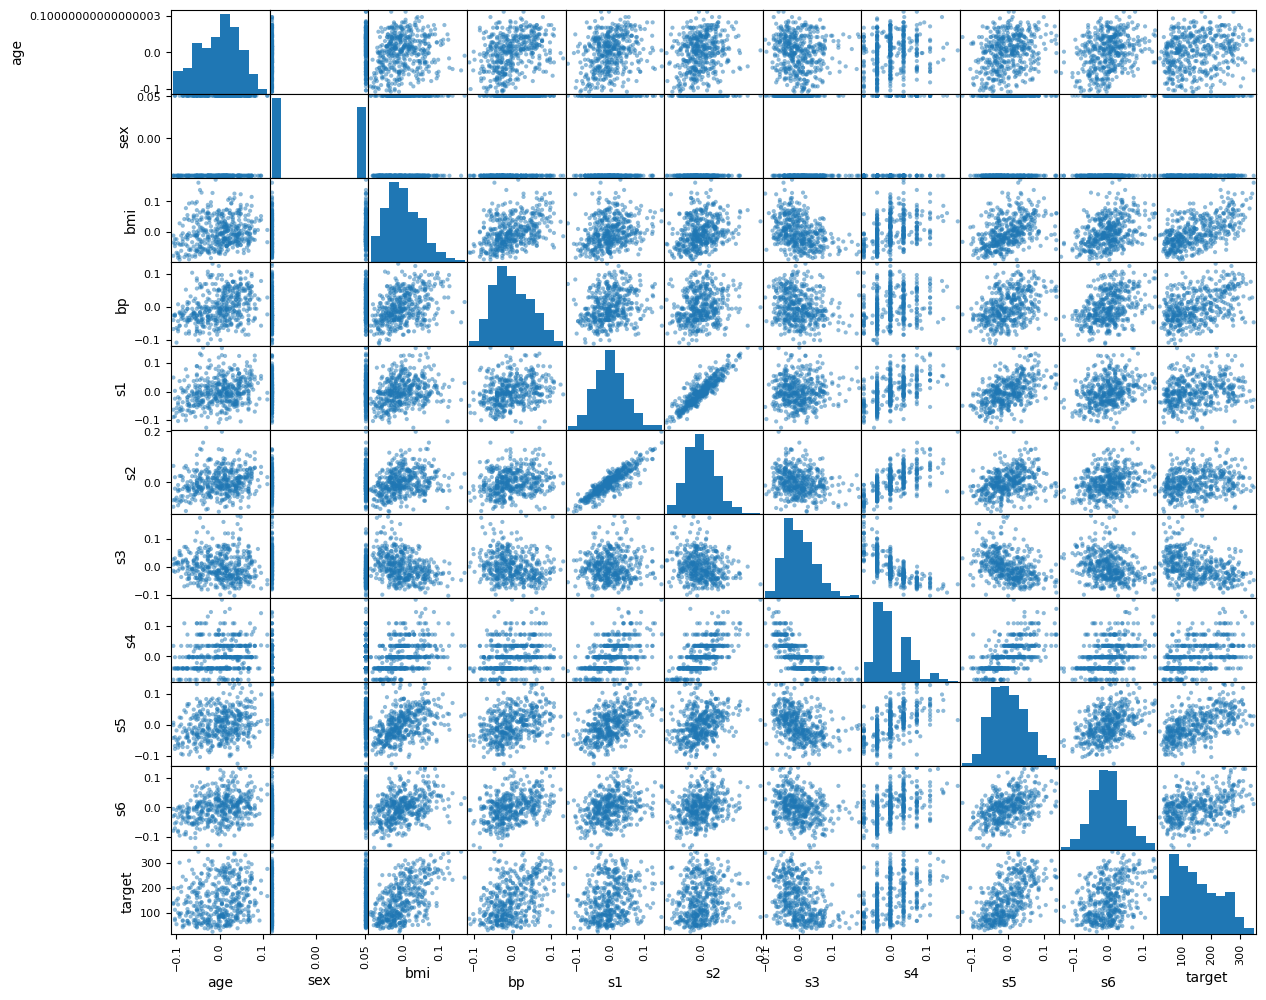

In [65]:
scatter_matrix(df, figsize=(14, 12))
plt.show()

### 1.3 Preparazione Training / Test set

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    shuffle=True,
    test_size=0.20,
    random_state=21,
    )

## 2. Confronto e Selezione Iniziale dei Modelli

1. Implementare e confrontare almeno quattro algoritmi di Regressione standard
2. Utilizzare la K-Fold Cross-Validation per valutare le prestazioni medie di ciascun modello sul set di training
3. Basare il confronto sulla metrica NMSE (Negative Mean Squared Error)

In [67]:
modelli = [
    ('Linear', LinearRegression()), 
    ('Ridge', Ridge()), 
    ('Lasso', Lasso()),
    ('DecisionTree', DecisionTreeRegressor()),
    ('Kneighbors', KNeighborsRegressor()),
    ('SVR', SVR())  
]

In [68]:
nomi = []
risultati = []
K = 10

for nome, modello in modelli:
    kfold = KFold(n_splits=K, shuffle=True, random_state=21)
    cv_results = cross_val_score(modello, X_train, y_train, cv=kfold, scoring='neg_mean_squared_error')
    nomi.append(nome)
    risultati.append(cv_results)
    print(f"{nome}: \t\tMedia: {cv_results.mean():.4f} \tSTD: {cv_results.std():.4f}")

Linear: 		Media: -2969.8297 	STD: 602.8522
Ridge: 		Media: -3376.2221 	STD: 586.6296
Lasso: 		Media: -3765.7154 	STD: 575.7833
DecisionTree: 		Media: -6080.2568 	STD: 1799.6491
Kneighbors: 		Media: -3591.9445 	STD: 897.6416
SVR: 		Media: -5004.4614 	STD: 806.5586


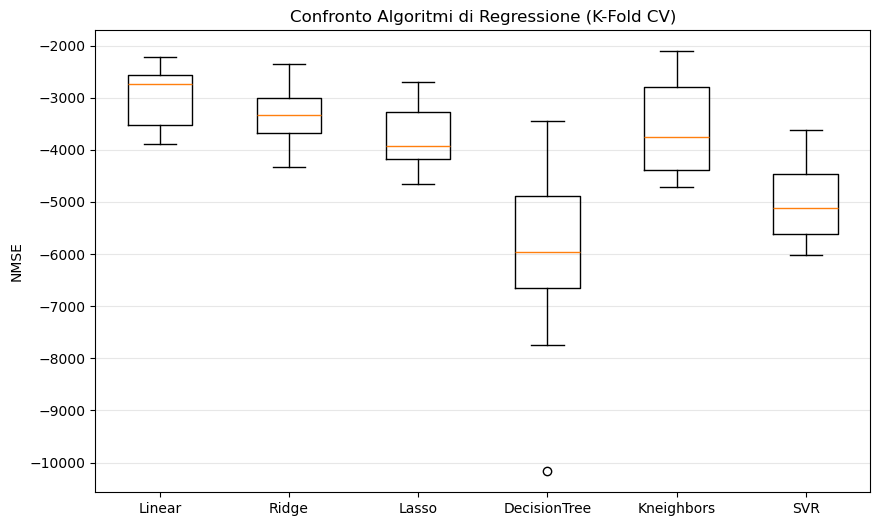

In [69]:
plt.figure(figsize=(10, 6))
plt.boxplot(risultati, tick_labels=nomi)
plt.ylabel('NMSE')
plt.title('Confronto Algoritmi di Regressione (K-Fold CV)')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

## 3. Hyperparameters Tuning

1. Grid Search per ottimizzare un iperparametro cruciale del modello scelto
2. Valutazione finale (MSE, R2) sul set di Test con il modello ottimizzato

**Scelta del modello da ottimizzare:** dal confronto in K-Fold CV, `LinearRegression` ha la media NMSE migliore con una deviazione standard contenuta, e resterebbe il modello di riferimento in termini di performance pura. Tuttavia non ha un iperparametro di regolarizzazione su cui abbia senso fare Grid Search.

Per la fase di tuning si sceglie quindi **Ridge** che, per valori piccoli, ha un comportamento che tende a quello di Linear

In [70]:
ridge = Ridge()

param_grid = {'alpha': np.logspace(-2, 2, 5)}

grid = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(f"alpha:\t\t{grid.best_params_['alpha']}")
print(f"CV NMSE:\t{grid.best_score_:.4f}")

alpha:		0.1
CV NMSE:	-3050.2741


In [71]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:\t{mse:.4f}")
print(f"R2:\t{r2:.4f}")


MSE:	3223.9211
R2:	0.4176


## 4. Analisi delle Performance

Learning Curves per il modello ottimizzato: valutare bias e varianza e commentare la tendenza a overfitting/underfitting.

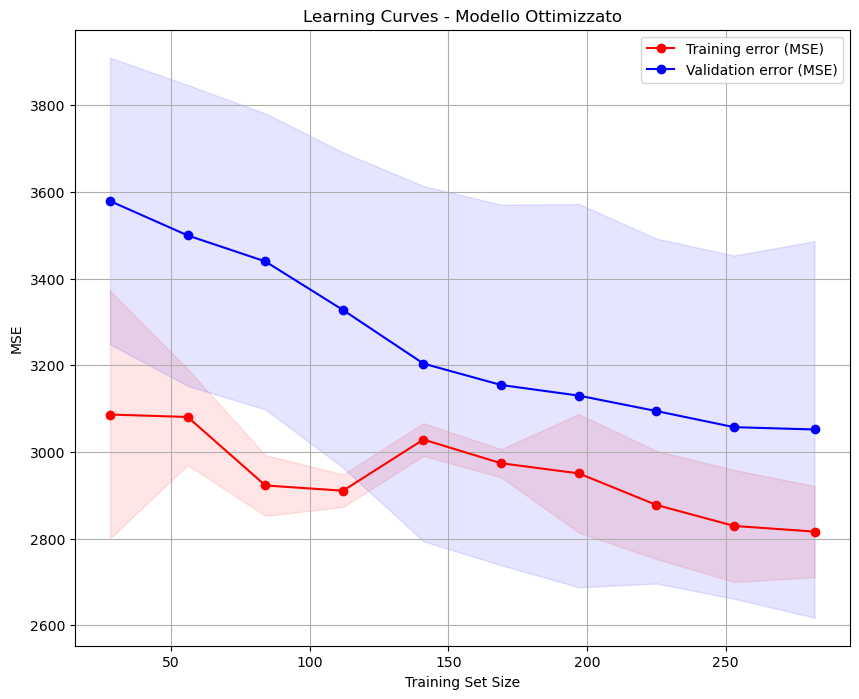

In [72]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10),
)

train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = -np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 8))
plt.plot(train_sizes, train_mean, 'o-', color='red', label='Training error (MSE)')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='red')
plt.plot(train_sizes, val_mean, 'o-', color='blue', label='Validation error (MSE)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='blue')
plt.xlabel('Training Set Size')
plt.ylabel('MSE')
plt.title('Learning Curves - Modello Ottimizzato')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

Underfitting (bias alto): il fatto che il training error resti comunque intorno a 2800-3000 (non scende quasi mai vicino a zero) e che il gap con la validation curve si stia già chiudendo con poche centinaia di esempi, indica che il modello non riesce a catturare bene il pattern nemmeno sui dati di training. Aggiungere più dati non aiuterebbe granché: il collo di bottiglia è la capacità del modello 'Ridge', lineare e regolarizzato, non la scarsità di dati. Questo indica che anche il modello 'LinearRegression' inizialmente indicato come scelta preferita per nmse e std non ridurebbe il bias.

## 5. Visualizzazione con Data Reduction

1. PCA per ridurre lo spazio delle feature a due dimensioni (PC1 & PC2)
2. Plot della superficie di regressione del modello ottimizzato nello spazio bidimensionale

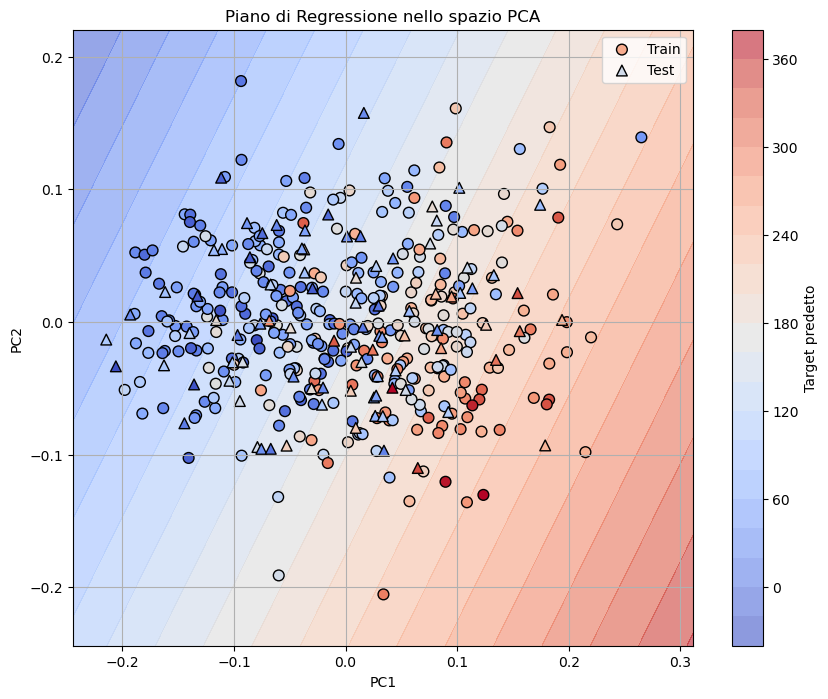

In [73]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

best_model.fit(X_train_pca, y_train)

x_margin = (X_train_pca[:, 0].max() - X_train_pca[:, 0].min()) * 0.1
y_margin = (X_train_pca[:, 1].max() - X_train_pca[:, 1].min()) * 0.1
x_min, x_max = X_train_pca[:, 0].min() - x_margin, X_train_pca[:, 0].max() + x_margin
y_min, y_max = X_train_pca[:, 1].min() - y_margin, X_train_pca[:, 1].max() + y_margin
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = best_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
surface = plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.6, levels=20)
plt.colorbar(surface, label='Target predetto')
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', s=60, label='Train')
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', edgecolors='k', marker='^', s=60, label='Test')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Piano di Regressione nello spazio PCA')
plt.legend()
plt.grid(True)
plt.show()